### Generalisation Validation

This notebook tests whether the main findings from Notebook 3 generalise beyond the JAMK ICT dataset used for the primary evaluation. 

LaBSE, identified as the strongest model, is applied to a separate dataset of bilingual course description pairs from JAMK's Business Information Technology degree programme. 

The BIT dataset was not used at any stage of model selection, threshold optimisation, or evaluation in Notebooks 1 to 3, making it a genuinely independent test of generalisation.

In [1]:
import pandas as pd
bit = pd.read_csv(r"C:\Users\madee\OneDrive\Desktop\thesis\Thesis Project - Final\data\raw\verified_final_dataset_BIT.csv")
print(bit.shape)
print(bit.columns.tolist())
print(bit['similarity_label'].value_counts())

(72, 16)
['course_id', 'title_fi', 'title_en', 'credits', 'outcomes_fi', 'outcomes_en', 'contents_fi', 'contents_en', 'assessment_fi', 'assessment_en', 'assessment_valid', 'similarity_label', 'label_note', 'label_timestamp', 'pair_type', 'pair_difficulty']
similarity_label
1    36
0    36
Name: count, dtype: int64


### Imports and Setup

In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             accuracy_score, roc_auc_score, roc_curve)
import unicodedata
import re
import spacy
import warnings
from transformers import logging as hf_logging

warnings.filterwarnings('ignore')
hf_logging.set_verbosity_error()

# Paths
bit_data_path = r"C:\Users\madee\OneDrive\Desktop\thesis\Thesis Project - Final\data\raw\verified_final_dataset_BIT.csv"
figures_dir = r"C:\Users\madee\OneDrive\Desktop\Thesis Project - Final\figures\main"
results_dir = r"C:\Users\madee\OneDrive\Desktop\Thesis Project - Final\data\results"
os.makedirs(results_dir, exist_ok=True)

nlp_fi = spacy.load("fi_core_news_sm")
nlp_en = spacy.load("en_core_web_sm")

### Loading and Preprocessing the BIT Dataset

The BIT dataset is loaded and passed through the same cleaning and configuration pipeline used in Notebook 1. 

This ensures that any performance difference observed on the BIT dataset reflects genuine generalisation ability rather than preprocessing inconsistency. 

The same three raw configurations are built: outcomes only, outcomes plus contents, and all three fields combined.

In [3]:
bit_df = pd.read_csv(bit_data_path)

print(f"BIT dataset loaded: {bit_df.shape}")
print(f"Label distribution:\n{bit_df['similarity_label'].value_counts()}\n")

# Same cleaning function as Notebook 1
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.strip()
    text = re.sub(r'[\u2022\u2023\u25E6\u2043\u2219]', '', text)
    text = unicodedata.normalize('NFC', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

text_columns = [
    'outcomes_fi', 'outcomes_en',
    'contents_fi', 'contents_en',
    'assessment_fi', 'assessment_en'
]

for col in text_columns:
    bit_df[col] = bit_df[col].apply(clean_text)

# Build three raw configurations
bit_df['config_1_fi'] = bit_df['outcomes_fi']
bit_df['config_1_en'] = bit_df['outcomes_en']

bit_df['config_2_fi'] = bit_df['outcomes_fi'] + ' ' + bit_df['contents_fi']
bit_df['config_2_en'] = bit_df['outcomes_en'] + ' ' + bit_df['contents_en']

bit_df['config_3_fi'] = bit_df['outcomes_fi'] + ' ' + bit_df['contents_fi'] + ' ' + bit_df['assessment_fi']
bit_df['config_3_en'] = bit_df['outcomes_en'] + ' ' + bit_df['contents_en'] + ' ' + bit_df['assessment_en']

# Verify no empty fields
print("Checking for empty configuration columns...")
all_clean = True
for col in ['config_1_fi', 'config_1_en', 'config_2_fi', 
            'config_2_en', 'config_3_fi', 'config_3_en']:
    empty = (bit_df[col].str.strip() == '').sum()
    if empty > 0:
        print(f"  WARNING: {col} has {empty} empty rows")
        all_clean = False
if all_clean:
    print("  All configuration columns clean.")

print(f"\nSample BIT pair (label=1):")
sample = bit_df[bit_df['similarity_label'] == 1].iloc[0]
print(f"  Finnish outcomes: {sample['outcomes_fi'][:200]}")
print(f"  English outcomes: {sample['outcomes_en'][:200]}")

BIT dataset loaded: (72, 16)
Label distribution:
similarity_label
1    36
0    36
Name: count, dtype: int64

Checking for empty configuration columns...
  All configuration columns clean.

Sample BIT pair (label=1):
  Finnish outcomes: Kurssin tavoite:UX-suunnittelun kurssilla opit perusperiaatteet käyttäjäkokemuksesta ja ihmiskeskeisestä suunnittelusta peleissä. Ymmärrät peruskäsitteet ja -käytännöt liittyen käytettävyyteen, käyttä
  English outcomes: The object of the course: In the UX Design course you will learn the basic principles of user experience and human centered design in games. You will understand the basic terminology and conventions r


### Generating LaBSE Embeddings for the BIT Dataset

LaBSE is loaded and applied to all three raw configurations of the BIT dataset. 

The same L2 normalization used in Notebook 2 is applied before similarity computation. No threshold optimisation is performed on the BIT dataset. 

Instead, the optimal threshold identified on the main ICT dataset in Notebook 3 is applied directly, making this a genuinely zero-shot generalisation test.

In [4]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = SentenceTransformer('sentence-transformers/LaBSE', device=str(device))

def l2_normalize(embeddings):
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    return embeddings / np.clip(norms, a_min=1e-10, a_max=None)

bit_embeddings = {}
configs = [1, 2, 3]
config_names = {
    1: 'Outcomes (Raw)',
    2: 'Outcomes + Contents (Raw)',
    3: 'Outcomes + Contents + Assessment (Raw)'
}

for config_num in configs:
    fi_texts = bit_df[f'config_{config_num}_fi'].tolist()
    en_texts = bit_df[f'config_{config_num}_en'].tolist()
    
    fi_emb = l2_normalize(model.encode(fi_texts, batch_size=32,
                                        show_progress_bar=False,
                                        convert_to_numpy=True))
    en_emb = l2_normalize(model.encode(en_texts, batch_size=32,
                                        show_progress_bar=False,
                                        convert_to_numpy=True))
    
    bit_embeddings[config_num] = (fi_emb, en_emb)
    print(f"  Config {config_num}: Finnish {fi_emb.shape}, English {en_emb.shape}")

print("\nEmbeddings generated successfully.")

Using device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  Config 1: Finnish (72, 768), English (72, 768)
  Config 2: Finnish (72, 768), English (72, 768)
  Config 3: Finnish (72, 768), English (72, 768)

Embeddings generated successfully.


### Evaluating on the BIT Dataset

The optimal threshold of 0.87 identified for LaBSE on the ICT dataset outcomes-only configuration in Notebook 3 is applied directly to the BIT dataset without any adjustment. 

This threshold was never exposed to BIT data at any point, making the evaluation a true zero-shot generalisation test across degree programmes.

In [5]:
# Optimal threshold from Notebook 3 full evaluation
ict_optimal_threshold = 0.87

bit_labels = bit_df['similarity_label'].values
bit_results = []

for config_num in configs:
    fi_emb, en_emb = bit_embeddings[config_num]
    sim_scores = np.sum(fi_emb * en_emb, axis=1)
    
    preds = (sim_scores >= ict_optimal_threshold).astype(int)
    
    precision = precision_score(bit_labels, preds, zero_division=0)
    recall = recall_score(bit_labels, preds, zero_division=0)
    f1 = f1_score(bit_labels, preds, zero_division=0)
    accuracy = accuracy_score(bit_labels, preds)
    auc = roc_auc_score(bit_labels, sim_scores)
    
    bit_results.append({
        'config': config_names[config_num],
        'threshold': ict_optimal_threshold,
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'f1': round(f1, 4),
        'accuracy': round(accuracy, 4),
        'auc': round(auc, 4)
    })

bit_results_df = pd.DataFrame(bit_results)
bit_results_path = os.path.join(results_dir, 'bit_generalisation_results.csv')
os.makedirs(results_dir, exist_ok=True)
bit_results_df.to_csv(bit_results_path, index=False)

print("BIT generalisation results:\n")
display(bit_results_df)

BIT generalisation results:



,config,threshold,precision,recall,f1,accuracy,auc
0,Outcomes (Raw),0.87,1.0,0.9444,0.9714,0.9722,0.9857
1,Outcomes + Contents (Raw),0.87,1.0,0.9444,0.9714,0.9722,0.9865
2,Outcomes + Contents + Assessment (Raw),0.87,1.0,0.9167,0.9565,0.9583,0.9857


LaBSE generalises strongly to the BIT dataset, achieving F1 0.9714 on both the outcomes-only and outcomes plus contents configurations using the threshold of 0.87 selected exclusively on the ICT dataset. 

Perfect precision across all three configurations means the model produced zero false positives on the BIT data, and the small number of missed pairs reflects the conservative nature of the fixed 
threshold rather than a fundamental limitation of the model.

The AUC values of 0.9857 to 0.9865 are consistent with the ICT dataset results, confirming that the model's discriminative ability transfers cleanly across degree programmes. 

These results indicate that LaBSE's performance is not specific to the ICT curriculum domain and that a single threshold calibrated on one JAMK degree programme can be applied reliably to another without retuning.

### Visualisation: BIT Generalisation Results

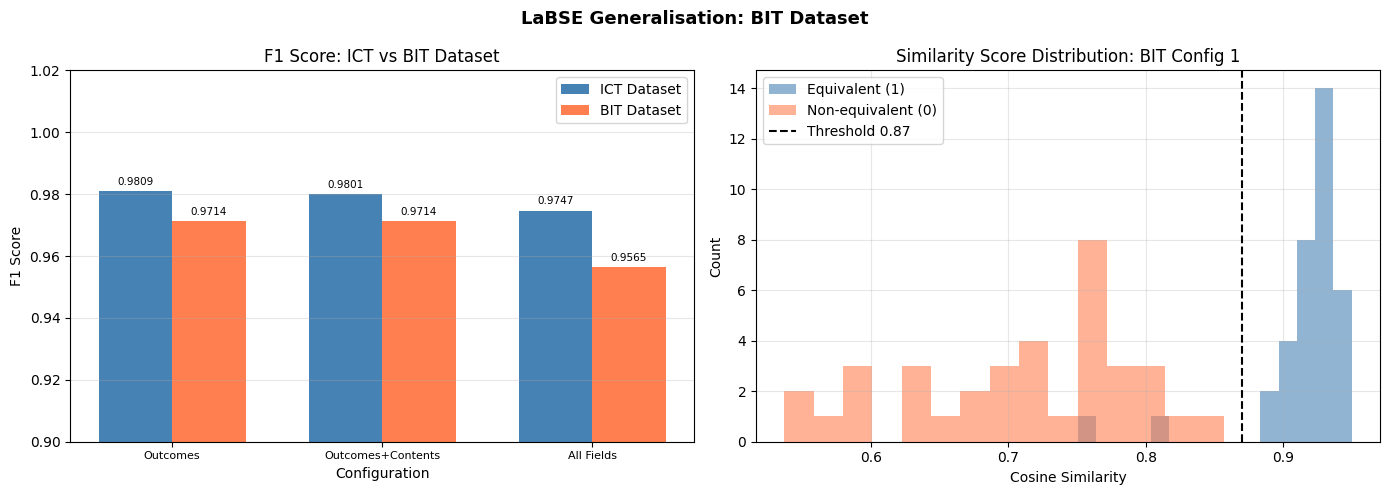

Plot saved: C:\Users\madee\OneDrive\Desktop\Thesis Project - Final\figures\main\bit_generalisation.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LaBSE Generalisation: BIT Dataset', fontsize=13, fontweight='bold')

# Plot 1: F1 comparison ICT vs BIT
ax1 = axes[0]
ict_f1 = [0.9809, 0.9801, 0.9747]
bit_f1 = bit_results_df['f1'].tolist()
x = np.arange(3)
width = 0.35
ax1.bar(x - width/2, ict_f1, width, label='ICT Dataset', color='steelblue')
ax1.bar(x + width/2, bit_f1, width, label='BIT Dataset', color='coral')
ax1.set_title('F1 Score: ICT vs BIT Dataset')
ax1.set_xlabel('Configuration')
ax1.set_ylabel('F1 Score')
ax1.set_xticks(x)
ax1.set_xticklabels(['Outcomes', 'Outcomes+Contents', 'All Fields'], fontsize=8)
ax1.legend()
ax1.set_ylim(0.90, 1.02)
ax1.grid(axis='y', alpha=0.3)

for i, (v1, v2) in enumerate(zip(ict_f1, bit_f1)):
    ax1.text(i - width/2, v1 + 0.002, f'{v1:.4f}', ha='center', fontsize=7.5)
    ax1.text(i + width/2, v2 + 0.002, f'{v2:.4f}', ha='center', fontsize=7.5)

# Plot 2: Similarity score distributions for BIT config 1
ax2 = axes[1]
fi_emb, en_emb = bit_embeddings[1]
sim_scores = np.sum(fi_emb * en_emb, axis=1)
pos_scores = sim_scores[bit_labels == 1]
neg_scores = sim_scores[bit_labels == 0]
ax2.hist(pos_scores, bins=15, alpha=0.6, color='steelblue', label='Equivalent (1)')
ax2.hist(neg_scores, bins=15, alpha=0.6, color='coral', label='Non-equivalent (0)')
ax2.axvline(x=0.87, color='black', linestyle='--', linewidth=1.5, label='Threshold 0.87')
ax2.set_title('Similarity Score Distribution: BIT Config 1')
ax2.set_xlabel('Cosine Similarity')
ax2.set_ylabel('Count')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(figures_dir, 'bit_generalisation.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved: {plot_path}")

### Notebook Summary

This notebook tested the generalisation of LaBSE to a completely independent dataset from JAMK's Business Information Technology degree programme. 

Using the threshold of 0.87 calibrated exclusively on the ICT dataset, LaBSE achieved F1 0.9714 on the BIT outcomes-only configuration with perfect precision and AUC of 0.9857. 

The similarity score distribution confirms that the clean separation between equivalent and non-equivalent pairs observed on the ICT dataset transfers directly to the BIT dataset without any retuning. 

These results support the conclusion that LaBSE with a fixed threshold of 0.87 is a reliable and transferable solution for 
bilingual course description equivalence detection across JAMK degree programmes.